<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">Graph Theory &amp; NetworkX Basics<div style="font-size:15px;font-weight:400;margin-top:6px;opacity:0.9;">Nodes, edges, degree, adjacency, connectivity &amp; traversal</div></div>

### What is a graph, really?

Forget the word "graph" for a second and just think of a **map of relationships**. A graph is simply a way of drawing **things** (called **nodes** or **vertices**) and the **connections** between them (called **edges**).

You already think in graphs every day, even if you never draw them:

- Your friends on a social app are nodes; "is friends with" is an edge.
- Cities are nodes; roads connecting them are edges.
- Bank accounts are nodes; money transfers between them are edges (this is exactly how fraud-detection systems look for suspicious rings of accounts).
- Web pages are nodes; hyperlinks between them are edges (this is literally how early Google ranked pages).

Formally, a graph is written as **G(V, E)**: **V** is the set of nodes (vertices) and **E** is the set of edges (connections). That's it — everything else in this notebook is just useful ways of *asking questions* about V and E.

**Why does this matter for data science / GNNs?** Graph Neural Networks (the next step after this notebook) take exactly this V/E structure as their input. Before we can teach a model to learn from a graph, we need to be completely comfortable *building*, *reading*, and *visualizing* graphs ourselves. That is the entire goal of this notebook — no modeling yet, just strong foundations.

**What we'll cover:**

1. Nodes and edges — building a graph by hand
2. Degree — who is the most "connected"?
3. Adjacency matrix and adjacency list — two ways to represent the same graph
4. Directed graphs — when relationships have a direction
5. Connectivity, paths, and traversal (BFS / DFS)
6. A gallery of classic graph shapes
7. Case study: Zachary's Karate Club, a famous real-world graph
8. Summary and what's next


<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">1. Setup</div>

We only need three libraries for this whole notebook:

- **NetworkX** — the standard Python library for creating, analyzing, and drawing graphs.
- **Matplotlib** — for plotting/visualizing graphs and charts.
- **NumPy** — for working with the adjacency matrix as a table of numbers.


In [21]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Make plots a consistent, readable size by default
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["font.size"] = 11

print("networkx version:", nx.__version__)


networkx version: 3.5


<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">2. The Building Blocks: Nodes and Edges</div>

A graph has two ingredients:

- **Nodes (vertices)** — the "things". People, cities, accounts, web pages...
- **Edges** — the connections between two nodes. An edge can be:
  - **Unweighted** (a friendship either exists or it doesn't), or **weighted** (a road has a distance, a transfer has a dollar amount).
  - **Undirected** (friendship goes both ways) or **directed** (A follows B doesn't mean B follows A) — more on this in Section 4.

Let's build a tiny, hand-made "friend group" graph — 6 people, a handful of friendships — so every idea below has a concrete example to point at.


In [22]:
# Create an empty undirected graph
G = nx.Graph()

# Add nodes (people)
people = ["Ejisay", "Harshit", "Vasant", "Saurav", "Vishal", "Somesh"]
G.add_nodes_from(people)

# Add edges (friendships)
friendships = [
    ("Ejisay", "Harshit"),
    ("Ejisay", "Vasant"),
    ("Harshit", "Vasant"),
    ("Vasant", "Saurav"),
    ("Saurav", "Vishal"),
    ("Saurav", "Somesh"),
    ("Vishal", "Somesh"),
]
G.add_edges_from(friendships)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Nodes: {list(G.nodes())}")
print(f"Edges: {list(G.edges())}")


Number of nodes: 6
Number of edges: 7
Nodes: ['Ejisay', 'Harshit', 'Vasant', 'Saurav', 'Vishal', 'Somesh']
Edges: [('Ejisay', 'Harshit'), ('Ejisay', 'Vasant'), ('Harshit', 'Vasant'), ('Vasant', 'Saurav'), ('Saurav', 'Vishal'), ('Saurav', 'Somesh'), ('Vishal', 'Somesh')]


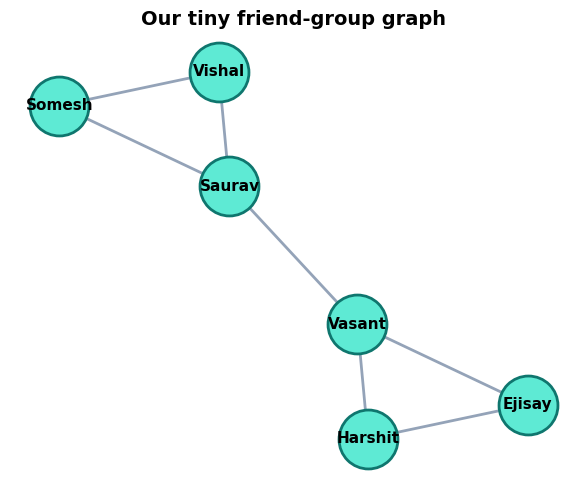

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)  # a layout algorithm that spaces nodes out nicely

nx.draw(
    G, pos, ax=ax, with_labels=True,
    node_color="#5eead4", edgecolors="#0f766e", linewidths=2,
    node_size=1800, font_size=11, font_weight="bold",
    edge_color="#94a3b8", width=2,
)
ax.set_title("Our tiny friend-group graph", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Reading the picture:** each circle is a node (a person), and each line is an edge (a friendship). Notice that Vasant and Saurav act like "bridges" — they're the only link between the {Ejisay, Harshit, Vasant} friend cluster and the {Saurav, Vishal, Somesh} cluster. Spotting structural roles like this by eye is exactly what graph algorithms do automatically, just at a much larger scale.


<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">3. Degree: How Connected Is Each Node?</div>

The **degree** of a node is simply the number of edges touching it — in our example, "how many friends does this person have?"

Degree is the simplest possible measure of importance in a graph: a node with high degree is a **hub**. In a social network, high-degree accounts are influencers; in a transaction network, an unusually high-degree account can be a red flag for fraud (one account transacting with dozens of others).


In [24]:
degrees = dict(G.degree())
for person, d in sorted(degrees.items(), key=lambda x: -x[1]):
    print(f"{person:8s} -> degree {d}")


Vasant   -> degree 3
Saurav   -> degree 3
Ejisay   -> degree 2
Harshit  -> degree 2
Vishal   -> degree 2
Somesh   -> degree 2


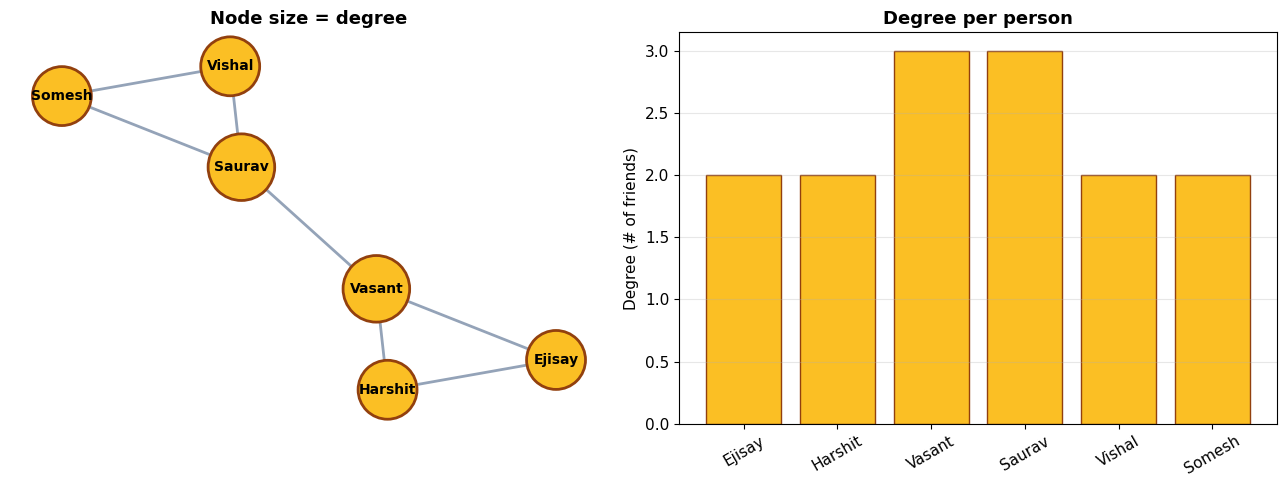

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph with node SIZE proportional to degree
pos = nx.spring_layout(G, seed=42)
node_sizes = [800 + 500 * degrees[n] for n in G.nodes()]
nx.draw(
    G, pos, ax=axes[0], with_labels=True,
    node_color="#fbbf24", edgecolors="#92400e", linewidths=2,
    node_size=node_sizes, font_size=10, font_weight="bold",
    edge_color="#94a3b8", width=2,
)
axes[0].set_title("Node size = degree", fontsize=13, fontweight="bold")

# Right: degree as a simple bar chart
names = list(degrees.keys())
values = list(degrees.values())
axes[1].bar(names, values, color="#fbbf24", edgecolor="#92400e")
axes[1].set_ylabel("Degree (# of friends)")
axes[1].set_title("Degree per person", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Vasant and Saurav have the highest degree (3 friends each) — matching what we already noticed visually: they're the two people holding the two friend clusters together.

<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">4. Adjacency Matrix and Adjacency List</div>

A picture is great for humans, but a computer (and a GNN!) needs graphs represented as numbers. There are two standard ways:

- **Adjacency matrix** — a V x V table (V = number of nodes) where a `1` at row *i*, column *j* means "node i is connected to node j" (and `0` means no edge). This is the representation GNNs use internally.
- **Adjacency list** — for each node, just list its neighbors directly. More memory-efficient for large, sparse graphs (most real-world graphs only have a few edges per node).

Same graph, two different "spellings."


In [26]:
# Adjacency matrix, as a NumPy array, in the same node order as `people`
A = nx.to_numpy_array(G, nodelist=people)
print("Adjacency matrix (rows/cols ordered as:", people, ")")
print(A.astype(int))


Adjacency matrix (rows/cols ordered as: ['Ejisay', 'Harshit', 'Vasant', 'Saurav', 'Vishal', 'Somesh'] )
[[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]


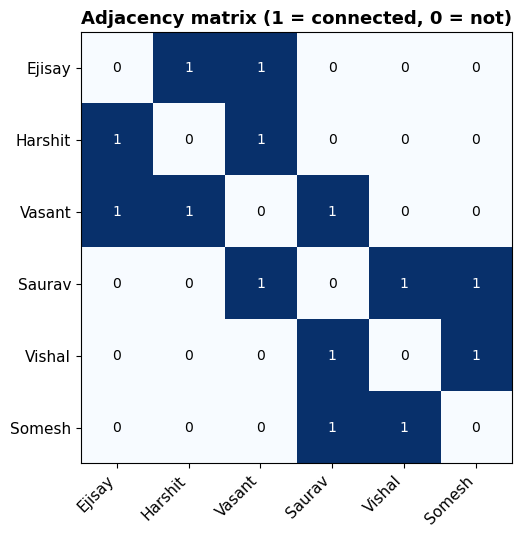

In [27]:
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(people)))
ax.set_yticks(range(len(people)))
ax.set_xticklabels(people, rotation=45, ha="right")
ax.set_yticklabels(people)

# annotate each cell with its 0/1 value
for i in range(len(people)):
    for j in range(len(people)):
        ax.text(j, i, int(A[i, j]), ha="center", va="center",
                 color="white" if A[i, j] == 1 else "black", fontsize=10)

ax.set_title("Adjacency matrix (1 = connected, 0 = not)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [28]:
print("Adjacency list (each person's direct neighbors):\n")
for person in people:
    neighbors = list(G.neighbors(person))
    print(f"{person:8s} -> {neighbors}")


Adjacency list (each person's direct neighbors):

Ejisay   -> ['Harshit', 'Vasant']
Harshit  -> ['Ejisay', 'Vasant']
Vasant   -> ['Ejisay', 'Harshit', 'Saurav']
Saurav   -> ['Vasant', 'Vishal', 'Somesh']
Vishal   -> ['Saurav', 'Somesh']
Somesh   -> ['Saurav', 'Vishal']


Notice the matrix is **symmetric** (the value at row Ejisay/col Harshit equals the value at row Harshit/col Ejisay) — that's always true for undirected graphs, because a friendship goes both ways. Also notice the diagonal is all zeros: nobody is "friends with themselves" here.


<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">5. When Direction Matters: Directed Graphs</div>

So far every edge has gone "both ways" — friendship is mutual. But lots of real relationships are **one-directional**:

- "follows" on social media (you can follow a celebrity without them following you back)
- "sent money to" in a transaction network
- "cites" between research papers

We model this with a **directed graph** (`DiGraph`), where each edge has an arrow. A node now has an **in-degree** (edges pointing in) and an **out-degree** (edges pointing out) instead of a single degree.


In [29]:
DG = nx.DiGraph()
DG.add_nodes_from(["Account_1", "Account_2", "Account_3", "Account_4"])
DG.add_edges_from([
    ("Account_1", "Account_2"),   # 1 sent money to 2
    ("Account_1", "Account_3"),   # 1 sent money to 3
    ("Account_2", "Account_3"),   # 2 sent money to 3
    ("Account_4", "Account_3"),   # 4 sent money to 3
])

print("In-degree (money received from):", dict(DG.in_degree()))
print("Out-degree (money sent to):     ", dict(DG.out_degree()))


In-degree (money received from): {'Account_1': 0, 'Account_2': 1, 'Account_3': 3, 'Account_4': 0}
Out-degree (money sent to):      {'Account_1': 2, 'Account_2': 1, 'Account_3': 0, 'Account_4': 1}


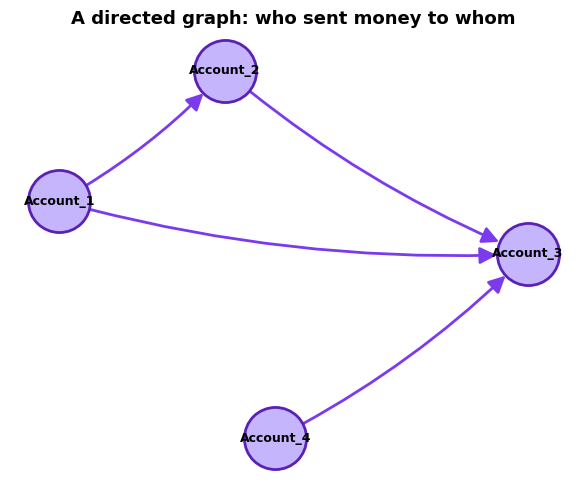

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
pos = nx.spring_layout(DG, seed=7)
nx.draw(
    DG, pos, ax=ax, with_labels=True,
    node_color="#c4b5fd", edgecolors="#5b21b6", linewidths=2,
    node_size=2000, font_size=9, font_weight="bold",
    edge_color="#7c3aed", width=2, arrowsize=25, arrowstyle="-|>",
    connectionstyle="arc3,rad=0.08",
)
ax.set_title("A directed graph: who sent money to whom", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Account_3 has in-degree 3 and out-degree 0** — it only ever *receives* money from three different accounts and never sends any out. In a real fraud-detection pipeline, that lopsided pattern (many senders, one receiver, no outgoing activity) is exactly the kind of shape that gets flagged for a closer look.

<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">6. Connectivity, Paths &amp; Traversal</div>

A few more essential questions we can ask about a graph:

- **Is it connected?** Can you get from any node to any other node by following edges? Or does the graph break into separate "islands" (**connected components**)?
- **What's a path?** A sequence of edges linking one node to another. The **shortest path** is the fewest number of edges needed.
- **Traversal** means visiting every reachable node in some systematic order. The two classic strategies:
  - **BFS (Breadth-First Search)** — explore layer by layer, like ripples spreading out from a stone dropped in water. Finds shortest paths.
  - **DFS (Depth-First Search)** — explore as deep as possible down one path before backtracking, like exploring a maze by always taking the next turn until you hit a dead end.

Let's add a second, disconnected mini-cluster to our friend graph so we can actually see an "island" and then traverse it.


In [31]:
G2 = G.copy()
G2.add_edges_from([("Gita", "Hari"), ("Hari", "Ivan")])  # a separate island, not linked to the rest

print("Is the whole graph connected?", nx.is_connected(G2))
print()
print("Connected components (the separate 'islands'):")
for i, comp in enumerate(nx.connected_components(G2), 1):
    print(f"  Component {i}: {sorted(comp)}")


Is the whole graph connected? False

Connected components (the separate 'islands'):
  Component 1: ['Ejisay', 'Harshit', 'Saurav', 'Somesh', 'Vasant', 'Vishal']
  Component 2: ['Gita', 'Hari', 'Ivan']


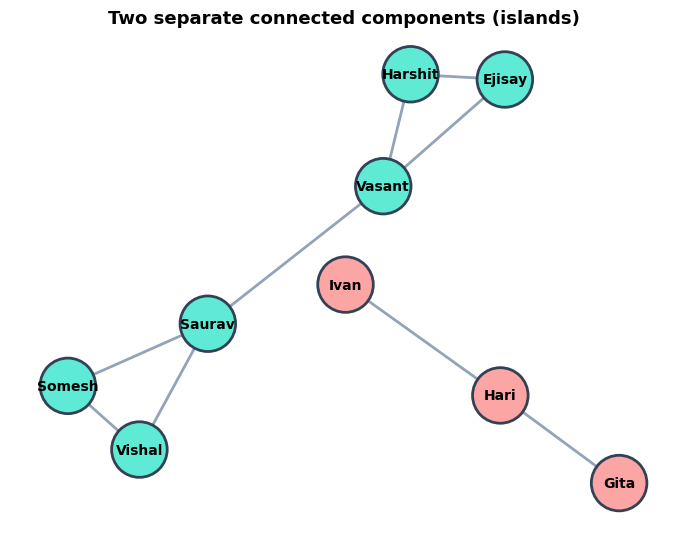

In [32]:
fig, ax = plt.subplots(figsize=(7, 5.5))
pos = nx.spring_layout(G2, seed=3, k=0.9)

# color each connected component differently
components = list(nx.connected_components(G2))
color_map = {}
palette = ["#5eead4", "#fca5a5"]
for comp, color in zip(components, palette):
    for node in comp:
        color_map[node] = color

nx.draw(
    G2, pos, ax=ax, with_labels=True,
    node_color=[color_map[n] for n in G2.nodes()],
    edgecolors="#334155", linewidths=2,
    node_size=1600, font_size=10, font_weight="bold",
    edge_color="#94a3b8", width=2,
)
ax.set_title("Two separate connected components (islands)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [33]:
# BFS and DFS, both starting from "Ejisay", restricted to her connected component
bfs_order = list(nx.bfs_tree(G2, source="Ejisay"))
dfs_order = list(nx.dfs_tree(G2, source="Ejisay"))

print("BFS visiting order from Ejisay:", bfs_order)
print("DFS visiting order from Ejisay:", dfs_order)


BFS visiting order from Ejisay: ['Ejisay', 'Harshit', 'Vasant', 'Saurav', 'Vishal', 'Somesh']
DFS visiting order from Ejisay: ['Ejisay', 'Harshit', 'Vasant', 'Saurav', 'Vishal', 'Somesh']


Notice BFS visits Ejisay's *direct* friends (Harshit, Vasant) before going further out, while DFS immediately follows one thread (Ejisay to Harshit to Vasant to Saurav...) as deep as it can before circling back. Same graph, same starting point, genuinely different order — which strategy you pick depends on what you're looking for (BFS for shortest paths, DFS for exhaustively exploring one branch first).


Shortest path from Ejisay to Somesh: Ejisay -> Vasant -> Saurav -> Somesh
Length: 3 edges


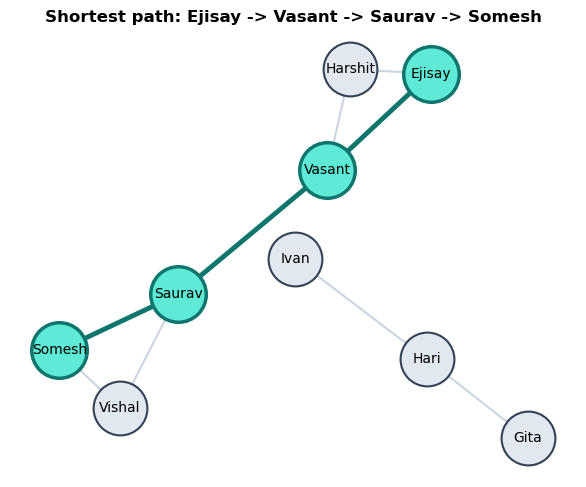

In [34]:
# Shortest path between two people who aren't directly friends
path = nx.shortest_path(G2, source="Ejisay", target="Somesh")
print(f"Shortest path from Ejisay to Somesh: {' -> '.join(path)}")
print(f"Length: {len(path) - 1} edges")

fig, ax = plt.subplots(figsize=(6, 5))
pos = nx.spring_layout(G2, seed=3, k=0.9)
path_edges = list(zip(path, path[1:]))

nx.draw(
    G2, pos, ax=ax, with_labels=True,
    node_color="#e2e8f0", edgecolors="#334155", linewidths=1.5,
    node_size=1500, font_size=10,
    edge_color="#cbd5e1", width=1.5,
)
# highlight the path on top
nx.draw_networkx_nodes(G2, pos, nodelist=path, node_color="#5eead4",
                        edgecolors="#0f766e", linewidths=2.5, node_size=1600, ax=ax)
nx.draw_networkx_edges(G2, pos, edgelist=path_edges, edge_color="#0f766e", width=3.5, ax=ax)

ax.set_title(f"Shortest path: {' -> '.join(path)}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">7. A Gallery of Classic Graph Shapes</div>

Before moving to a real dataset, it helps to build a visual vocabulary of a few named graph "shapes" that show up constantly in papers and libraries:

- **Path graph** — nodes in a single line, like a chain.
- **Cycle graph** — a path that loops back on itself, like a ring.
- **Star graph** — one central node connected to every other node, and nothing else.
- **Complete graph** — every node is connected to every other node.
- **Random (Erdos-Renyi) graph** — each possible edge is included with some fixed probability. Useful for simulating "realistic-looking" random networks.


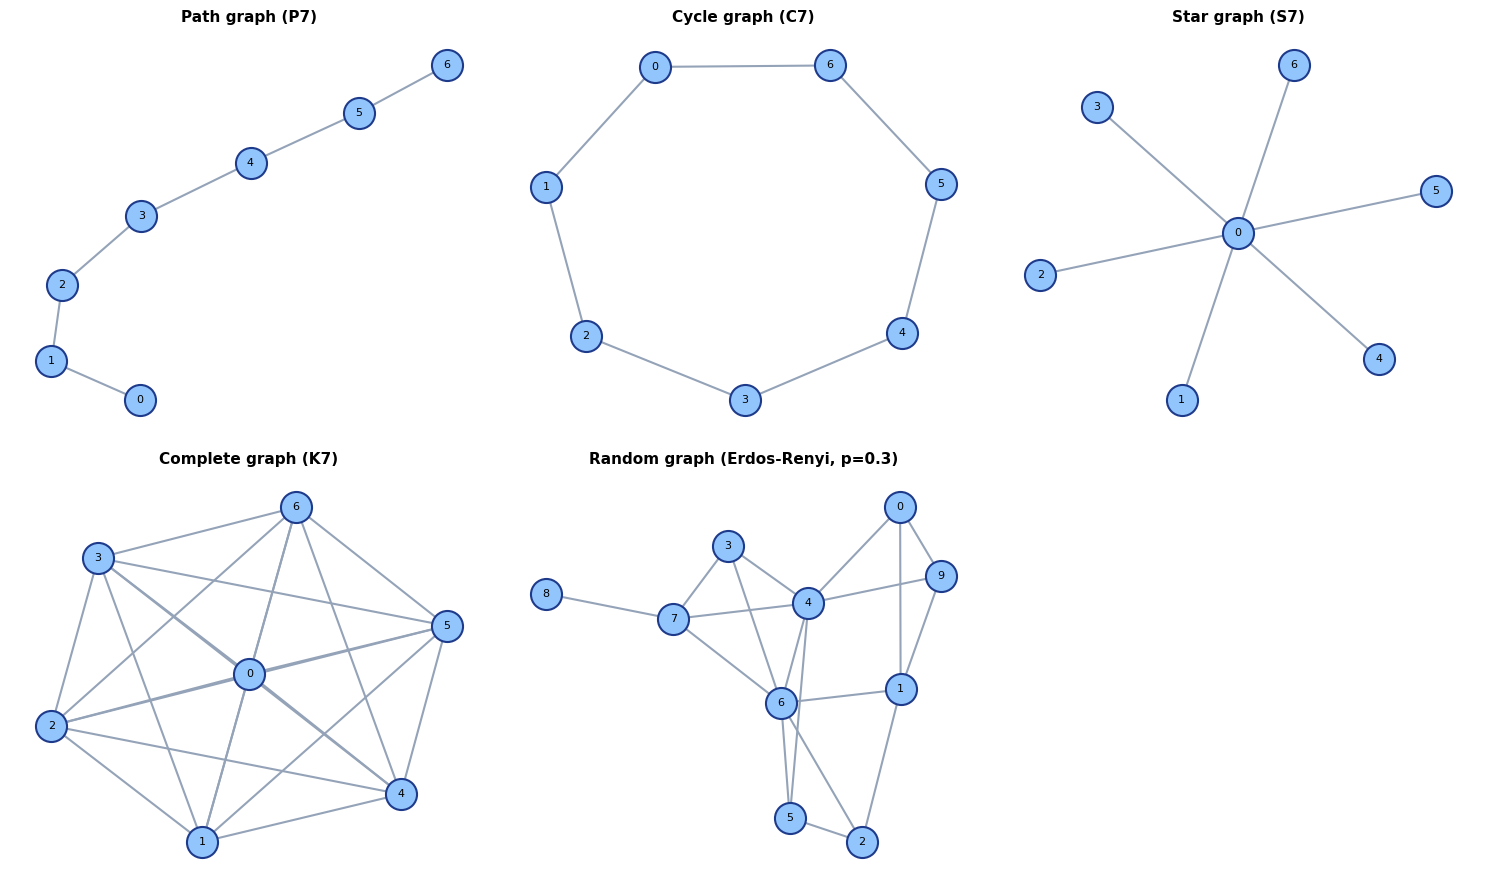

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

graphs_to_show = [
    ("Path graph (P7)", nx.path_graph(7)),
    ("Cycle graph (C7)", nx.cycle_graph(7)),
    ("Star graph (S7)", nx.star_graph(6)),
    ("Complete graph (K7)", nx.complete_graph(7)),
    ("Random graph (Erdos-Renyi, p=0.3)", nx.erdos_renyi_graph(10, 0.3, seed=1)),
]

for ax, (title, g) in zip(axes, graphs_to_show):
    pos = nx.spring_layout(g, seed=0)
    nx.draw(
        g, pos, ax=ax, with_labels=True,
        node_color="#93c5fd", edgecolors="#1e3a8a", linewidths=1.5,
        node_size=500, font_size=8,
        edge_color="#94a3b8", width=1.5,
    )
    ax.set_title(title, fontsize=11, fontweight="bold")

axes[-1].axis("off")  # 6th subplot unused
plt.tight_layout()
plt.show()


These aren't just toys — real networks are often *mixtures* of these shapes. A hub-and-spoke corporate structure looks like a star; a social clique looks like a small complete graph; and most large real-world networks (like the one below) look statistically similar to a random graph mixed with a few dense clusters.

<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">8. Case Study: Zachary's Karate Club</div>

Time to move from toy examples to a real, famous dataset. In the early 1970s, sociologist **Wayne Zachary** studied the friendships among 34 members of a university karate club for three years. Partway through his study, the club's members had a falling-out between the instructor ("Mr. Hi") and the club president ("Officer"), and the club **split into two separate clubs**.

The remarkable part: Zachary showed that just by looking at the *friendship graph structure* — who trained with whom, ignoring everything else about the people — you could predict almost exactly how the club would split. This became one of the most famous toy datasets in network science, and it's built directly into NetworkX.

This is also a nice preview of why GNNs are powerful: the raw connections between people carried real predictive information, before we even looked at any other attribute.


In [36]:
KG = nx.karate_club_graph()

print(f"Number of members (nodes): {KG.number_of_nodes()}")
print(f"Number of friendships (edges): {KG.number_of_edges()}")
print(f"Average degree: {2 * KG.number_of_edges() / KG.number_of_nodes():.2f}")
print(f"Graph density: {nx.density(KG):.3f}  (fraction of all possible edges that actually exist)")
print(f"Is the whole club connected? {nx.is_connected(KG)}")


Number of members (nodes): 34
Number of friendships (edges): 78
Average degree: 4.59
Graph density: 0.139  (fraction of all possible edges that actually exist)
Is the whole club connected? True


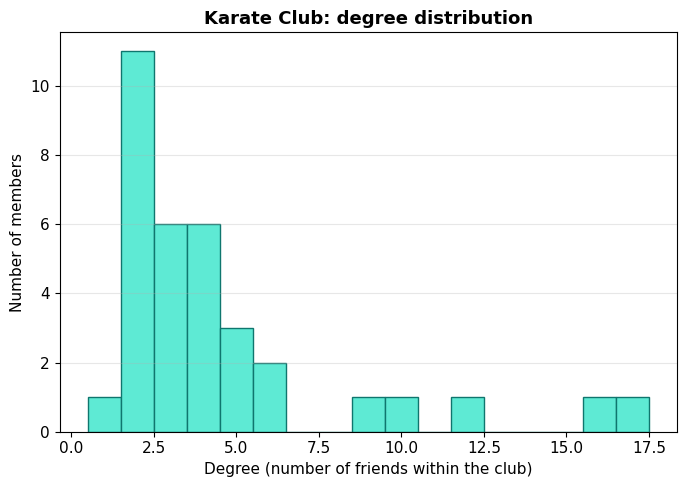

Most connected member: node 33 with degree 17


In [37]:
degree_values = [d for _, d in KG.degree()]

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(degree_values, bins=range(1, max(degree_values) + 2), color="#5eead4",
        edgecolor="#0f766e", align="left")
ax.set_xlabel("Degree (number of friends within the club)")
ax.set_ylabel("Number of members")
ax.set_title("Karate Club: degree distribution", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Most connected member: node {max(dict(KG.degree()), key=dict(KG.degree()).get)} "
      f"with degree {max(degree_values)}")


Most members have just a handful of friends, but a couple of members (the instructor and the president, unsurprisingly) are clear hubs with far more connections than everyone else — a pattern called a **long-tailed degree distribution**, which shows up in almost every real-world network from social graphs to the internet itself.

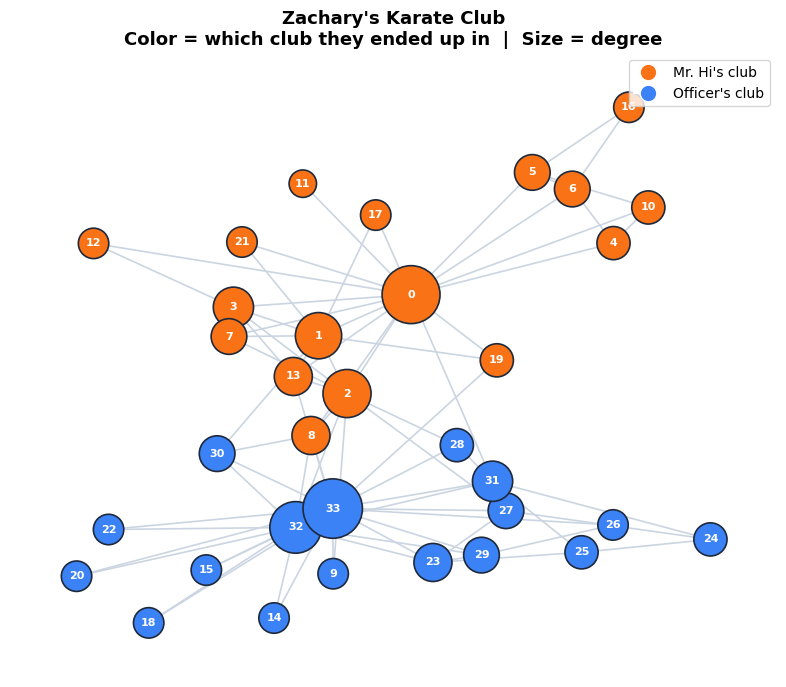

In [38]:
# Each node already carries a 'club' attribute: which of the two post-split clubs it ended up in
club_labels = nx.get_node_attributes(KG, "club")  # 'Mr. Hi' or 'Officer'
color_by_club = ["#f97316" if club_labels[n] == "Mr. Hi" else "#3b82f6" for n in KG.nodes()]
size_by_degree = [300 + 90 * KG.degree(n) for n in KG.nodes()]

fig, ax = plt.subplots(figsize=(8, 7))
pos = nx.spring_layout(KG, seed=42, k=0.4)

nx.draw(
    KG, pos, ax=ax, with_labels=True,
    node_color=color_by_club, edgecolors="#1e293b", linewidths=1.2,
    node_size=size_by_degree, font_size=8, font_color="white", font_weight="bold",
    edge_color="#cbd5e1", width=1.2,
)
ax.set_title(
    "Zachary's Karate Club\nColor = which club they ended up in  |  Size = degree",
    fontsize=13, fontweight="bold",
)
# simple legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker="o", color="w", label="Mr. Hi's club", markerfacecolor="#f97316", markersize=12),
    Line2D([0], [0], marker="o", color="w", label="Officer's club", markerfacecolor="#3b82f6", markersize=12),
]
ax.legend(handles=legend_elems, loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()


Look closely: the orange (Mr. Hi) and blue (Officer) members aren't randomly scattered — they form two visually distinct, densely-connected neighborhoods, with only a few edges crossing between them. That's exactly the structural fault line along which the club actually split in real life.

In [39]:
# A quick community-detection check: can an algorithm find that split using ONLY the graph structure?
from networkx.algorithms.community import greedy_modularity_communities

detected_communities = greedy_modularity_communities(KG)
print(f"Algorithm found {len(detected_communities)} communities based purely on graph structure:")
for i, community in enumerate(detected_communities, 1):
    print(f"  Community {i} ({len(community)} members): {sorted(community)}")

# How well does this line up with the real Mr. Hi vs Officer split?
mr_hi_members = {n for n, c in club_labels.items() if c == "Mr. Hi"}
officer_members = {n for n, c in club_labels.items() if c == "Officer"}
print(f"\nReal split       -> Mr. Hi: {sorted(mr_hi_members)}")
print(f"Real split       -> Officer: {sorted(officer_members)}")


Algorithm found 3 communities based purely on graph structure:
  Community 1 (17 members): [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
  Community 2 (9 members): [1, 2, 3, 7, 9, 12, 13, 17, 21]
  Community 3 (8 members): [0, 4, 5, 6, 10, 11, 16, 19]

Real split       -> Mr. Hi: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]
Real split       -> Officer: [9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [40]:
# Shortest path & "distance" example within the karate club
node_a, node_b = 0, 33  # the instructor (0) and the club president (33)
path = nx.shortest_path(KG, source=node_a, target=node_b)
print(f"Shortest path between member {node_a} and member {node_b}: {path}")
print(f"Distance: {len(path) - 1} hops")
print(f"Average shortest path length across the whole club: {nx.average_shortest_path_length(KG):.2f} hops")


Shortest path between member 0 and member 33: [0, 8, 33]
Distance: 2 hops
Average shortest path length across the whole club: 2.41 hops


Even in a club of 34 people, any two members are on average less than 2.5 friendship-hops apart — a small real-world example of the "small world" effect (the same idea behind "six degrees of separation").

**Purely from graph structure** — no attributes, no modeling, just nodes/edges/degree/community-detection — we already recovered a strong signal about a real social split. That is precisely the intuition a Graph Neural Network builds on: it takes this same structure, adds learnable features, and pushes the idea much further.


<div style="background:linear-gradient(90deg,#1f2937,#0f766e);color:#ffffff;font-family:Segoe UI,Arial,sans-serif;font-size:26px;font-weight:700;text-align:center;border-radius:14px;padding:18px 10px;margin-bottom:6px;">9. Summary &amp; What's Next</div>

**What we covered in this notebook:**

We built graphs by hand, learned how to read node/edge counts, computed and visualized **degree** to spot hubs, converted between the **adjacency matrix** and **adjacency list** representations, explored **directed** graphs and in/out-degree, checked **connectivity** and ran **BFS/DFS traversal** plus shortest-path search, toured a **gallery of classic graph shapes**, and finished with a real dataset — **Zachary's Karate Club** — where pure graph structure predicted a real-world social split.

**Why this matters going forward:** every one of these ideas — nodes, edges, degree, the adjacency matrix, neighborhoods, connectivity — is the exact vocabulary that Graph Neural Networks are built on. A GNN's core operation, *message passing*, is literally "each node looks at its neighbors (found via the adjacency matrix) and updates itself based on what it sees." Having these fundamentals solid, and being comfortable building/visualizing graphs in NetworkX, is what makes the next step — actually building a GNN — click much faster.

**Coming up next:** applying these same ideas to a real project dataset, and then building our first Graph Neural Network on top of it.
